# 02 · Statistical Summary and Visualization
Univariate and bivariate exploration of the cleaned Titanic data.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../data/processed/titanic_clean.csv')
df['AgeGroup'] = pd.Categorical(df['AgeGroup'], ['Child','Teen','Young Adult','Adult','Senior'], ordered=True)
print(df.shape)

(891, 17)


## 1. Statistical summary

In [2]:
df[['Age','Fare','SibSp','Parch','FamilySize']].describe().round(2)

,Age,Fare,SibSp,Parch,FamilySize
count,891.00,891.00,891.00,891.00,891.00
mean,29.39,32.20,0.52,0.38,1.90
std,13.26,49.69,1.10,0.81,1.61
min,0.42,0.00,0.00,0.00,1.00
25%,21.00,7.91,0.00,0.00,1.00
50%,30.00,14.45,0.00,0.00,1.00
75%,35.00,31.00,1.00,0.00,2.00
max,80.00,512.33,8.00,6.00,11.00


In [3]:
num = df[['Age','Fare','FamilySize']]
pd.DataFrame({'skewness': num.skew(), 'kurtosis': num.kurtosis()}).round(2)

,skewness,kurtosis
Age,0.44,0.78
Fare,4.79,33.40
FamilySize,2.73,9.16


In [4]:
df.describe(include='object').T[['count','unique','top','freq']]

/tmp/ipykernel_413/445160469.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T[['count','unique','top','freq']]


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Embarked,891,3,S,646
Title,891,5,Mr,517


**Reading:** `Fare` is strongly right-skewed (a few very expensive tickets); `Age` is close to symmetric with a slight right tail.

## 2. Univariate analysis

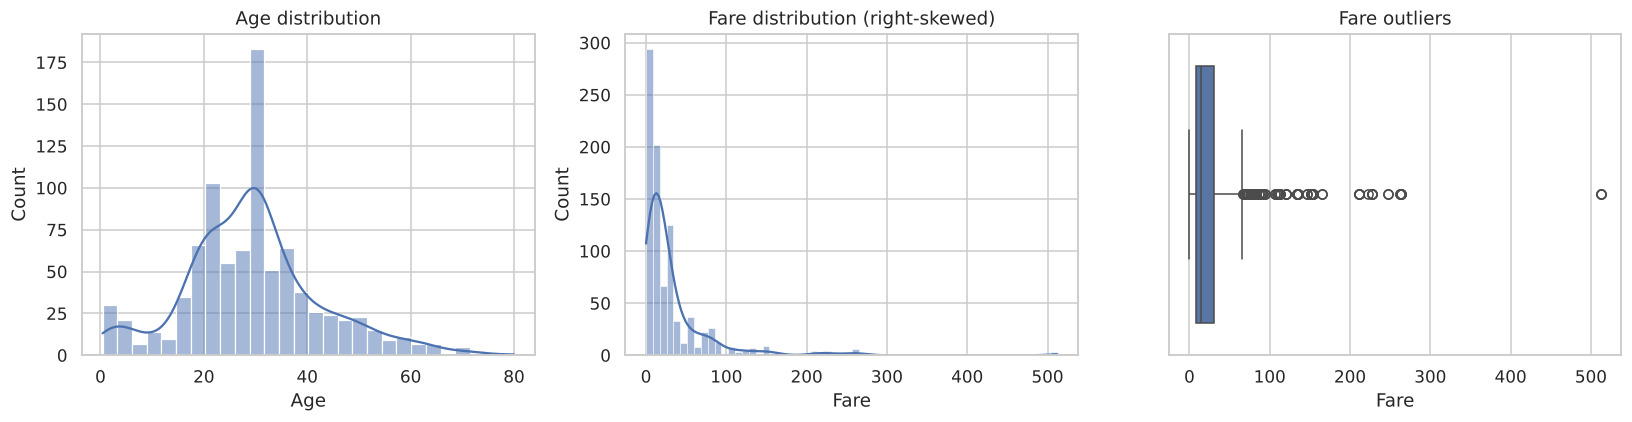

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['Age'], kde=True, ax=ax[0]); ax[0].set_title('Age distribution')
sns.histplot(df['Fare'], kde=True, ax=ax[1]); ax[1].set_title('Fare distribution (right-skewed)')
sns.boxplot(x=df['Fare'], ax=ax[2]); ax[2].set_title('Fare outliers')
plt.tight_layout(); plt.savefig('../images/01_distributions.png', bbox_inches='tight'); plt.show()

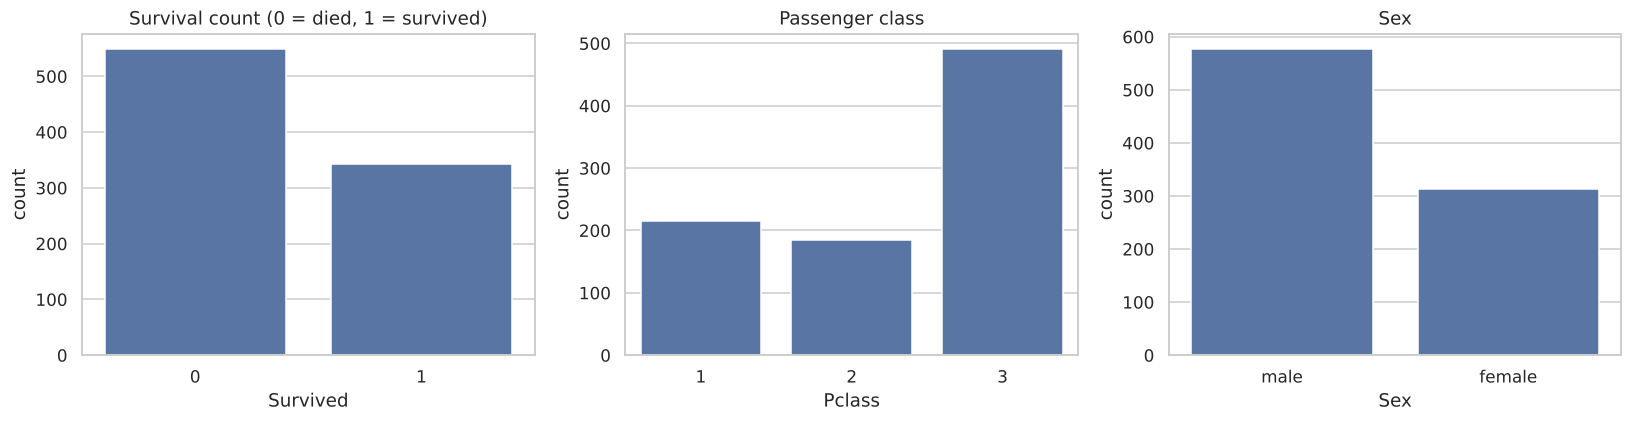

Overall survival rate: 38.4%


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))
sns.countplot(data=df, x='Survived', ax=ax[0]); ax[0].set_title('Survival count (0 = died, 1 = survived)')
sns.countplot(data=df, x='Pclass', ax=ax[1]); ax[1].set_title('Passenger class')
sns.countplot(data=df, x='Sex', ax=ax[2]); ax[2].set_title('Sex')
plt.tight_layout(); plt.savefig('../images/02_counts.png', bbox_inches='tight'); plt.show()
print(f"Overall survival rate: {df['Survived'].mean():.1%}")

## 3. Survival rate by key factors

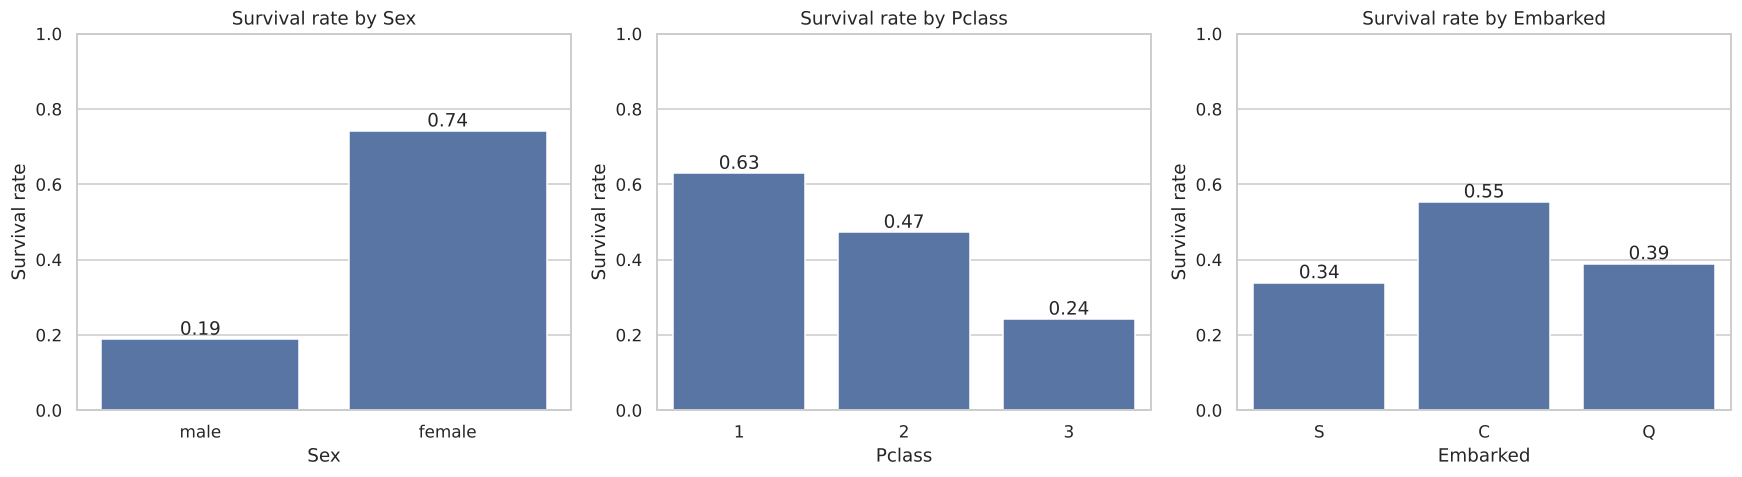

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16,4.5))
for a, col in zip(ax, ['Sex','Pclass','Embarked']):
    sns.barplot(data=df, x=col, y='Survived', errorbar=None, ax=a)
    a.set_ylim(0,1); a.set_ylabel('Survival rate'); a.set_title(f'Survival rate by {col}')
    for c in a.containers: a.bar_label(c, fmt='%.2f')
plt.tight_layout(); plt.savefig('../images/03_survival_by_factor.png', bbox_inches='tight'); plt.show()

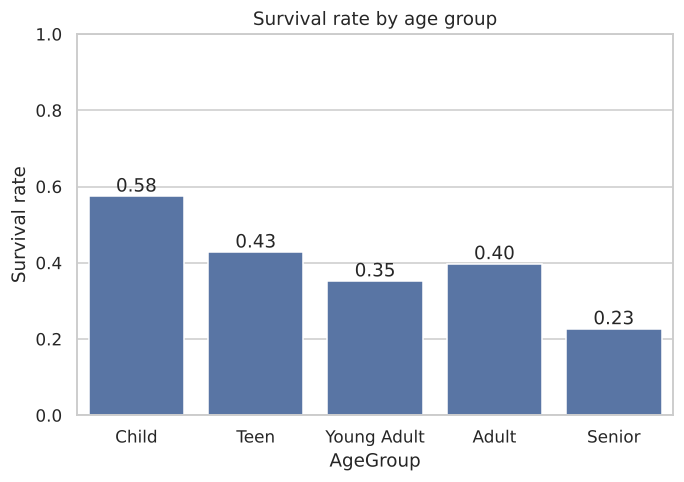

In [8]:
plt.figure(figsize=(7,4.5))
ax = sns.barplot(data=df, x='AgeGroup', y='Survived', errorbar=None)
ax.set_ylim(0,1); ax.set_ylabel('Survival rate'); ax.set_title('Survival rate by age group')
for c in ax.containers: ax.bar_label(c, fmt='%.2f')
plt.savefig('../images/04_survival_by_age.png', bbox_inches='tight'); plt.show()

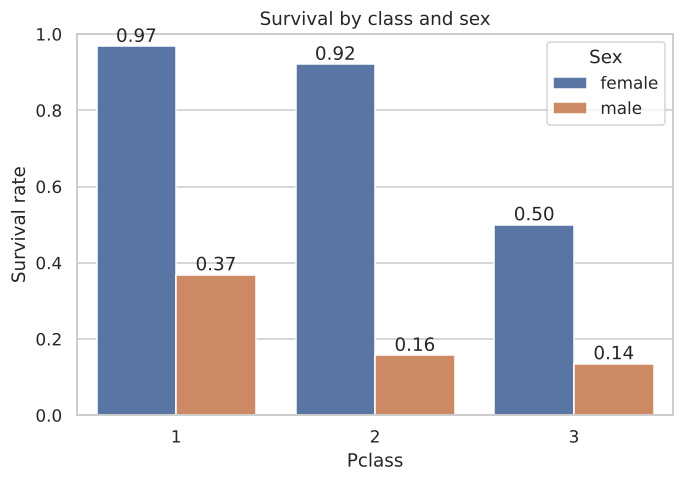

Sex,female,male
Pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


In [9]:
plt.figure(figsize=(7,4.5))
ax = sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', errorbar=None)
ax.set_ylim(0,1); ax.set_ylabel('Survival rate'); ax.set_title('Survival by class and sex')
for c in ax.containers: ax.bar_label(c, fmt='%.2f')
plt.savefig('../images/05_class_sex_survival.png', bbox_inches='tight'); plt.show()
df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean').round(3)

## 4. Fare, family size and survival

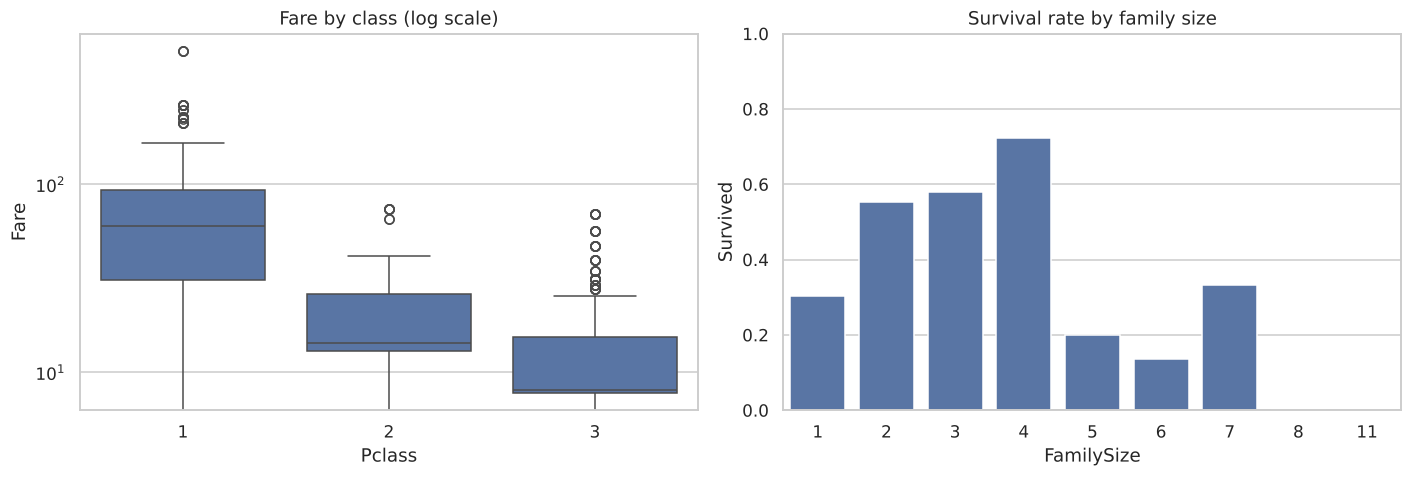

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
sns.boxplot(data=df, x='Pclass', y='Fare', ax=ax[0]); ax[0].set_yscale('log'); ax[0].set_title('Fare by class (log scale)')
sns.barplot(data=df, x='FamilySize', y='Survived', errorbar=None, ax=ax[1]); ax[1].set_ylim(0,1); ax[1].set_title('Survival rate by family size')
plt.tight_layout(); plt.savefig('../images/06_fare_family.png', bbox_inches='tight'); plt.show()

In [11]:
df.groupby('FamilySize')['Survived'].agg(['count','mean']).round(3)

,count,mean
FamilySize,,
1,537,0.304
2,161,0.553
3,102,0.578
4,29,0.724
5,15,0.200
6,22,0.136
7,12,0.333
8,6,0.000
11,7,0.000
